### HuyIGW04 - MLP for Fashion-MNIST Data  

In [1]:
from torchvision.datasets import FashionMNIST
from torch.utils.data import DataLoader
from torchvision import transforms
import  matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import numpy as np

In [2]:
# for mean and std 
trans = transforms.Compose([
    transforms.ToTensor()
])

train = FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=trans
)

test = FashionMNIST(
    root='data',
    transform=trans,
    train=False
)

# std phải tính bằng E[X^2] - E[X]^2, với E[X]^2 chính là mean**2
mean = 0
ss_pixel = 0
num_pixel = 0
for x,_ in train:
    # tính mean bằng cách flatten input x và sử dụng torch.mean()
    mean += torch.mean(x.flatten()).item()

    # E[X^2]: X gồm N samples, mỗi sample là một ảnh, mỗi ảnh có n pixel -> 
    # Tổng của bình phương mỗi pixel (ss_pixel) chia cho tổng số pixel trong toàn bộ tập X (num_pixel = 784 x batch_size)
    ss_pixel += torch.sum((x*x).flatten()).item()
    num_pixel += len(x.flatten())
mean = mean/len(train)
std = (ss_pixel/num_pixel- mean**2)**0.5
print('mean: ', mean)
print('std: ', std)

mean:  0.2860406030333911
std:  0.35302425010486427


In [3]:
# with mean and std from input of train set, we find the best solution for normalization 
trans = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (mean,),
        (std,)
        )
])

train_set = FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=trans
)

test_set = FashionMNIST(
    root='data',
    train=False,
    transform=trans
)

# check flatten
train_img, train_label = train_set[0]
train_img.shape

torch.Size([1, 28, 28])

In [4]:
# batch devision
trainloader = DataLoader(
    dataset=train_set,
    batch_size=1024, 
    num_workers=10,
    shuffle=True, 
    # generator=torch.Generator(device='cuda')
)

testloader = DataLoader(
    dataset=test_set,
    batch_size=1024,
    shuffle=False,
    num_workers=10,

)


for _, (X_train_batch, y_train_batch) in enumerate(trainloader):
    print('train set:')
    print('input: ', X_train_batch.shape)
    print('label: ', y_train_batch.shape)
    break

for _,(X_test_batch, y_test_batch) in enumerate(testloader):
    print('test set:')
    print('input: ', X_test_batch.shape)
    print('label: ', y_test_batch.shape)
    break

train set:
input:  torch.Size([1024, 1, 28, 28])
label:  torch.Size([1024])
test set:
input:  torch.Size([1024, 1, 28, 28])
label:  torch.Size([1024])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


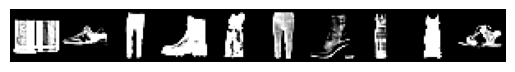

In [5]:
for _, (X_batch, y_batch) in enumerate(trainloader):
    img_show = torchvision.utils.make_grid(X_batch[:10], nrow=10)
    img_show = img_show.numpy()
    img_show = np.transpose(img_show, (1, 2, 0))

plt.axis('off')
plt.imshow(img_show)
plt.show()

In [6]:
epochs = 20
losses = []
acc = []
t10k_losses = []
t10k_acc = []
input_features = 784
output_features = 10
    

criterion = nn.CrossEntropyLoss()

# MLP model - 2 hidden layer
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(input_features, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, output_features)
).to('cuda')

optimizer = optim.SGD(model.parameters(), lr=0.01)
for epoch in range(epochs):
    losses_epoch = 0
    acc_epoch = 0
    cnt = 0
    
    model.train()
    for _, (X_batch, y_batch) in enumerate(trainloader):
        X_batch = X_batch.to('cuda')
        y_batch = y_batch.to('cuda')
        y_batch_hat = model(X_batch)
        loss_batch = criterion(y_batch_hat, y_batch)
        losses_epoch += loss_batch.item()
        cnt += 1
        optimizer.zero_grad()
        loss_batch.backward()
        optimizer.step()
    
        # metric
        y_batch_hat = torch.argmax(y_batch_hat, axis=1)
        acc_batch = torch.sum(y_batch_hat == y_batch)/len(y_batch_hat)
        acc_epoch += acc_batch.item()
    
    # loss train
    losses_epoch = losses_epoch/cnt
    losses.append(losses_epoch)

    # acc train
    acc_epoch = acc_epoch/cnt
    acc.append(acc_epoch)

    # metric
    model.eval()
    test_losses_epoch = 0
    test_acc_epoch = 0
    test_cnt = 0
    with torch.no_grad():
        for _, (X_test, y_test) in enumerate(testloader):
            X_test = X_test.to('cuda')
            y_test = y_test.to('cuda')
            y_test_hat = model(X_test)
            test_loss_batch = criterion(y_test_hat, y_test)
            test_losses_epoch += test_loss_batch.item()
            test_cnt += 1

            # accuracy
            y_test_hat_acc = torch.argmax(y_test_hat, axis=1)
            test_acc_batch = torch.sum(y_test_hat_acc == y_test)/len(y_test)
            test_acc_epoch += test_acc_batch.item()



    # loss test
    test_losses_epoch = test_losses_epoch/test_cnt
    t10k_losses.append(test_losses_epoch)

    # acc test
    test_acc_epoch = test_acc_epoch/test_cnt
    t10k_acc.append(test_acc_epoch)


    print(f"EPOCH {epoch + 1}:       loss_train = {round(losses_epoch, 4)}      ---    loss_test = {round(test_losses_epoch, 4)}   \
        ---     accuracy_train = {round(acc_epoch*100, 4)} %     ---    acccuracy_test = {round(test_acc_epoch*100, 4)} %")

EPOCH 1:       loss_train = 2.1468      ---    loss_test = 1.9436           ---     accuracy_train = 34.7918 %     ---    acccuracy_test = 48.0443 %
EPOCH 2:       loss_train = 1.673      ---    loss_test = 1.4053           ---     accuracy_train = 54.2628 %     ---    acccuracy_test = 60.176 %
EPOCH 3:       loss_train = 1.2169      ---    loss_test = 1.08           ---     accuracy_train = 65.089 %     ---    acccuracy_test = 68.2099 %
EPOCH 4:       loss_train = 0.9875      ---    loss_test = 0.9253           ---     accuracy_train = 70.0157 %     ---    acccuracy_test = 70.6615 %
EPOCH 5:       loss_train = 0.8667      ---    loss_test = 0.834           ---     accuracy_train = 72.2506 %     ---    acccuracy_test = 72.3298 %
EPOCH 6:       loss_train = 0.789      ---    loss_test = 0.7712           ---     accuracy_train = 73.9459 %     ---    acccuracy_test = 73.7719 %
EPOCH 7:       loss_train = 0.7347      ---    loss_test = 0.7261           ---     accuracy_train = 75.1247 %   

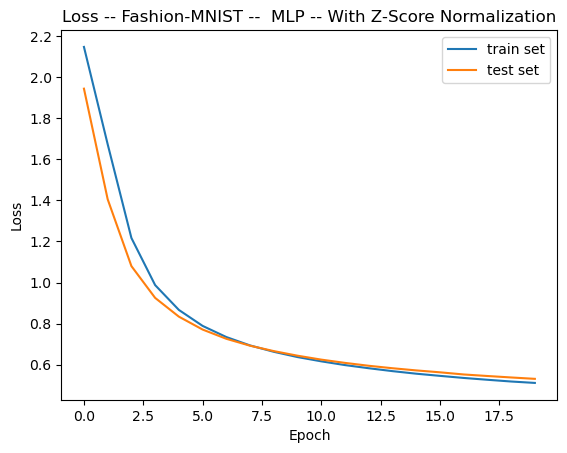

In [7]:
plt.plot(losses, label='train set')
plt.plot(t10k_losses, label='test set')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss -- Fashion-MNIST --  MLP -- With Z-Score Normalization')
plt.legend()
plt.show()

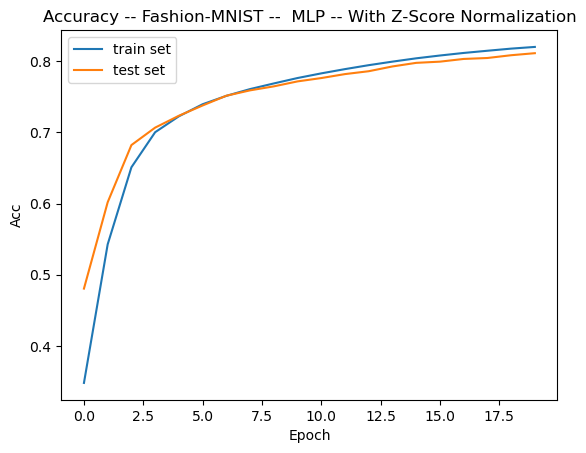

In [8]:
plt.plot(acc, label='train set')
plt.plot(t10k_acc, label='test set')
plt.xlabel('Epoch')
plt.ylabel('Acc')
plt.title('Accuracy -- Fashion-MNIST --  MLP -- With Z-Score Normalization')
plt.legend()
plt.show()